CN7023-SEMCD-14_UdayKiranMudu

In [ ]:
# ==============================================================================
# STEP 1: ENVIRONMENT SETUP
# ==============================================================================
!pip install pyspark -q

import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Initialize Spark Session
spark = (
    SparkSession.builder.appName('Airline_Delay_Analysis')
    .master('local[*]')
    .getOrCreate()
)

print('Spark Session successfully initialized!')

# Optional: Mount Google Drive if loading file from Drive
# drive.mount('/content/drive')

Spark Session successfully initialized!


In [ ]:
# ==============================================================================
# STEP 2 & 3: DATA LOADING & PRE-PROCESSING
# ==============================================================================
# File path to the dataset
file_path = 'Airline_Delay_Cause.csv'  # Update path if using Google Drive: '/content/drive/MyDrive/Airline_Delay_Cause.csv'

# Load CSV dataset into PySpark DataFrame
df_raw = spark.read.csv(file_path, header=True, inferSchema=True)

# 1. Inspect Schema and Initial Row Count
print('Original Dataset Count:', df_raw.count())
df_raw.printSchema()

# 2. Null Checks & Pre-processing (Imputation & Simple Outlier Rules)
# Identify numerical columns for imputation
numeric_cols = [
    'arr_flights',
    'arr_del15',
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct',
    'arr_cancelled',
    'arr_diverted',
    'arr_delay',
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay',
]

# Rule 1: Impute missing numerical values with 0.0
df_cleaned = df_raw.fillna(0.0, subset=numeric_cols)

# Rule 2: Outlier / Filtering rule: Remove invalid records where total arrival flights <= 0
df = df_cleaned.filter(F.col('arr_flights') > 0)

print('Cleaned Dataset Count:', df.count())
df.show(5)

Original Dataset Count: 15834
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)

Cleaned Dataset Count: 15825
+----+-----+-------+---------

In [ ]:
# ==============================================================================
# STEP 4: OVERALL FLIGHT DELAY PERCENTAGE OVER TIME
# ==============================================================================
# Aggregation in PySpark
delay_over_time_df = df.groupBy('year', 'month').agg(
    (F.sum(F.col('arr_del15')) / F.sum(F.col('arr_flights')) * 100).alias(
        'delay_percentage'
    )
).orderBy('year', 'month')

# Convert aggregated Spark DataFrame to Pandas for plotting
delay_over_time_pd = delay_over_time_df.toPandas()

# Plotting
plt.figure(figsize=(12, 6))
time_labels = (
    delay_over_time_pd['year'].astype(str)
    + '-'
    + delay_over_time_pd['month'].astype(str).str.zfill(2)
)
plt.plot(
    time_labels,
    delay_over_time_pd['delay_percentage'],
    marker='o',
    linestyle='-',
)
plt.title('Overall Flight Delay Percentage Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# STEP 5: HIGHEST DELAY PERCENTAGE BY AIRLINE
# ==============================================================================
# Calculate average delay percentage per carrier
delay_by_airline_df = df.groupBy('carrier_name').agg(
    (F.sum(F.col('arr_del15')) / F.sum(F.col('arr_flights')) * 100).alias(
        'average_delay_percentage'
    )
).orderBy(F.col('average_delay_percentage').desc())

# Convert to Pandas
delay_by_airline_pd = delay_by_airline_df.toPandas()

# Plotting
plt.figure(figsize=(14, 7))
plt.bar(
    delay_by_airline_pd['carrier_name'],
    delay_by_airline_pd['average_delay_percentage'],
    color='skyblue',
)
plt.xlabel('Airline Carrier')
plt.ylabel('Average Delay Percentage (%)')
plt.title('Average Flight Delay Percentage by Airline')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

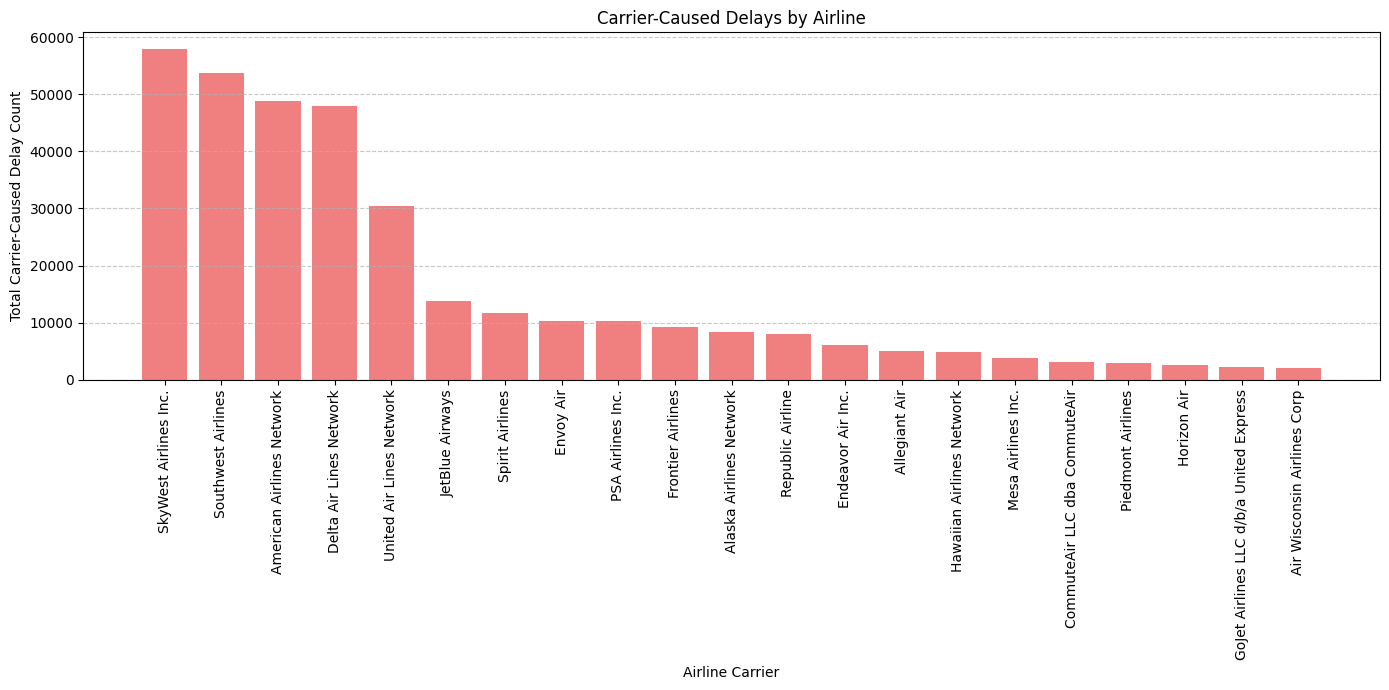

In [ ]:
# ==============================================================================
# STEP 6: MOST CARRIER-CAUSED DELAYS BY AIRLINE
# ==============================================================================
# Calculate total carrier-caused delay count per carrier
carrier_caused_delays_df = df.groupBy('carrier_name').agg(
    F.sum(F.col('carrier_ct')).alias('total_carrier_caused_delays')
).orderBy(F.col('total_carrier_caused_delays').desc())

# Convert to Pandas
carrier_caused_delays_pd = carrier_caused_delays_df.toPandas()

# Plotting
plt.figure(figsize=(14, 7))
plt.bar(
    carrier_caused_delays_pd['carrier_name'],
    carrier_caused_delays_pd['total_carrier_caused_delays'],
    color='lightcoral',
)
plt.xlabel('Airline Carrier')
plt.ylabel('Total Carrier-Caused Delay Count')
plt.title('Carrier-Caused Delays by Airline')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

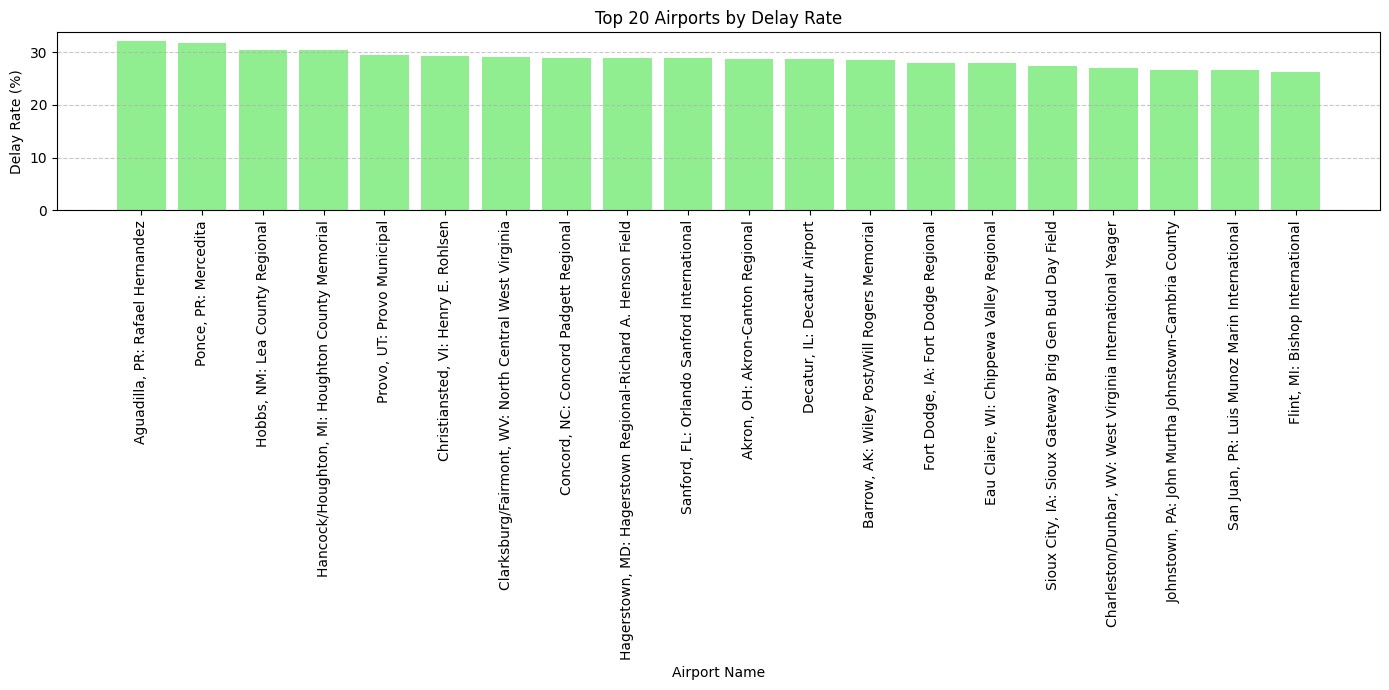

In [ ]:
# ==============================================================================
# STEP 7: TOP 20 AIRPORTS BY DELAY RATE
# ==============================================================================
# Calculate delay rate per airport
airport_delay_rates_df = df.groupBy('airport_name').agg(
    (F.sum(F.col('arr_del15')) / F.sum(F.col('arr_flights')) * 100).alias(
        'delay_rate'
    )
).orderBy(F.col('delay_rate').desc())

# Limit top 20 for visual clarity and convert to Pandas
airport_delay_rates_pd = airport_delay_rates_df.limit(20).toPandas()

# Plotting
plt.figure(figsize=(14, 7))
plt.bar(
    airport_delay_rates_pd['airport_name'],
    airport_delay_rates_pd['delay_rate'],
    color='lightgreen',
)
plt.xlabel('Airport Name')
plt.ylabel('Delay Rate (%)')
plt.title('Top 20 Airports by Delay Rate')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

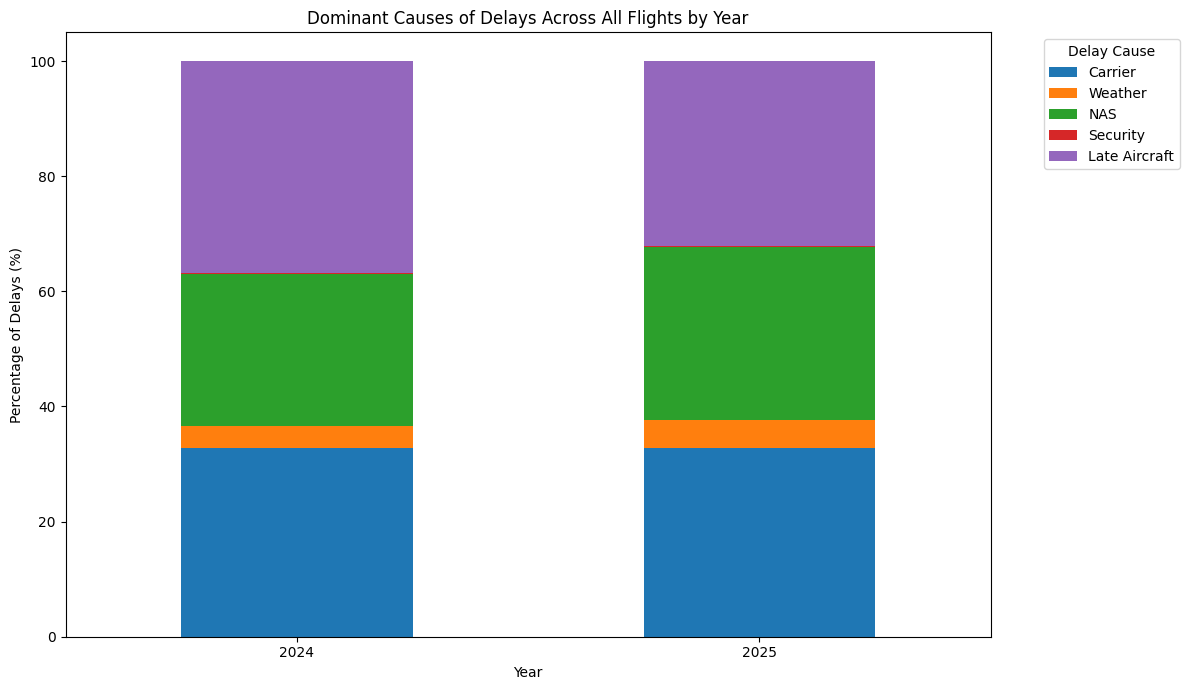

In [ ]:
# ==============================================================================
# STEP 8 & 9: DOMINANT CAUSES OF DELAYS ACROSS ALL FLIGHTS BY YEAR
# ==============================================================================
# Aggregate total delay counts per cause by year
delay_causes_df = df.groupBy('year').agg(
    F.sum(F.col('carrier_ct')).alias('carrier_caused'),
    F.sum(F.col('weather_ct')).alias('weather_caused'),
    F.sum(F.col('nas_ct')).alias('nas_caused'),
    F.sum(F.col('security_ct')).alias('security_caused'),
    F.sum(F.col('late_aircraft_ct')).alias('late_aircraft_caused'),
).orderBy('year')

# Convert to Pandas for percentage calculation and stacked bar chart
delay_causes_pd = delay_causes_df.toPandas()

# Calculate total delays and percentage breakdown
cause_cols = [
    'carrier_caused',
    'weather_caused',
    'nas_caused',
    'security_caused',
    'late_aircraft_caused',
]
delay_causes_pd['total_delays'] = delay_causes_pd[cause_cols].sum(axis=1)

pct_cols = []
for col_name in cause_cols:
  pct_col = col_name + '_pct'
  delay_causes_pd[pct_col] = (
      delay_causes_pd[col_name] / delay_causes_pd['total_delays']
  ) * 100
  pct_cols.append(pct_col)

# Plotting Stacked Bar Chart
ax = (
    delay_causes_pd.set_index('year')[pct_cols]
    .plot(kind='bar', stacked=True, figsize=(12, 7))
)
plt.title('Dominant Causes of Delays Across All Flights by Year')
plt.xlabel('Year')
plt.ylabel('Percentage of Delays (%)')
plt.xticks(rotation=0)
plt.legend(
    ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft'],
    title='Delay Cause',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# STEP 10: DELAY CAUSES VARIATION BY MONTH (SEASONALITY)
# ==============================================================================
# Aggregate delay counts by month
delay_causes_by_month_df = df.groupBy('month').agg(
    F.sum(F.col('carrier_ct')).alias('carrier_caused'),
    F.sum(F.col('weather_ct')).alias('weather_caused'),
    F.sum(F.col('nas_ct')).alias('nas_caused'),
    F.sum(F.col('security_ct')).alias('security_caused'),
    F.sum(F.col('late_aircraft_ct')).alias('late_aircraft_caused'),
).orderBy('month')

# Convert to Pandas
delay_causes_by_month_pd = delay_causes_by_month_df.toPandas()

# Plotting Multi-line Chart
plt.figure(figsize=(14, 7))
month_names = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

plt.plot(
    delay_causes_by_month_pd['month'],
    delay_causes_by_month_pd['carrier_caused'],
    label='Carrier Caused',
    marker='o',
)
plt.plot(
    delay_causes_by_month_pd['month'],
    delay_causes_by_month_pd['weather_caused'],
    label='Weather Caused',
    marker='o',
)
plt.plot(
    delay_causes_by_month_pd['month'],
    delay_causes_by_month_pd['nas_caused'],
    label='NAS Caused',
    marker='o',
)
plt.plot(
    delay_causes_by_month_pd['month'],
    delay_causes_by_month_pd['security_caused'],
    label='Security Caused',
    marker='o',
)
plt.plot(
    delay_causes_by_month_pd['month'],
    delay_causes_by_month_pd['late_aircraft_caused'],
    label='Late Aircraft Caused',
    marker='o',
)

plt.title('Delay Causes Variation by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Total Delay Count')
plt.xticks(range(1, 13), month_names)
plt.legend(
    title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left'
)
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 11: AVERAGE FLIGHT DELAY PERCENTAGE BY MONTH
# ==============================================================================
# Calculate monthly average delay percentage
delay_pct_month_df = df.groupBy('month').agg(
    (F.sum(F.col('arr_del15')) / F.sum(F.col('arr_flights')) * 100).alias(
        'average_delay_percentage'
    )
).orderBy('month')

# Convert to Pandas
delay_pct_month_pd = delay_pct_month_df.toPandas()

# Plotting Line Chart
plt.figure(figsize=(12, 6))
plt.plot(
    delay_pct_month_pd['month'],
    delay_pct_month_pd['average_delay_percentage'],
    marker='o',
    linestyle='-',
    color='purple',
)
plt.title('Average Flight Delay Percentage by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay Percentage (%)')
plt.xticks(range(1, 13), month_names)
plt.grid(True)
plt.tight_layout()
plt.show()